# Онлайн-продажи

### Шаг 1. Импортируйте библиотеки

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

### Шаг 2. Импортируем датасет
[ссылка](https://drive.google.com/file/d/15TDU30hgLI_0db8Li_oUQBBPAPik8O-8/view?usp=sharing) для загрузки

In [3]:
path = '../../../../datasets/Online_Retail.csv'
online_rt = pd.read_csv(path,  encoding='latin1')

### Шаг 2. Импортируем датасет
[ссылка](https://drive.google.com/file/d/15TDU30hgLI_0db8Li_oUQBBPAPik8O-8/view?usp=sharing) для загрузки

### Шаг 3. Прочитайте в переменную online_rt
Если вышла ошибка кодировки, задайте `encoding = 'latin1'`

### Шаг 4. Удалите заказы с отрицательным Quantity. Сколько таких заказов?

In [4]:
print(online_rt.loc[online_rt['Quantity'] < 0].shape[0])
online_rt = online_rt.loc[online_rt['Quantity'] >= 0]

10624


### Шаг 5. Добавьте колонку Revenue = Quantity * UnitPrice

In [5]:
online_rt = online_rt.assign(Revenue = online_rt.loc[:, 'Quantity']*online_rt.loc[:, 'UnitPrice'])

### Шаг 6. Приведите колонку InvoiceDate в правильный формат
`pd.to_datetime(df[col])`

In [6]:
online_rt['InvoiceDate'] = pd.to_datetime(pd.to_datetime(online_rt['InvoiceDate']))

### Шаг 7. Нарисуйте bar chart с 10 странами с максимальным Revenue

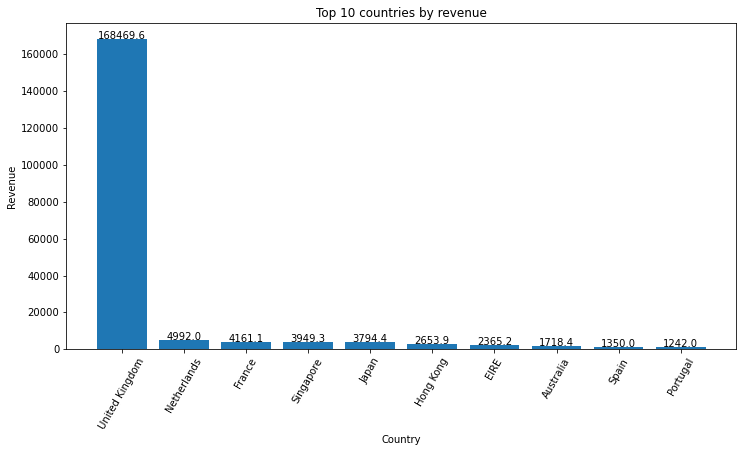

In [7]:
fig, ax = plt.subplots(figsize = (12, 6))

ax.bar('Country', 'Revenue', data=online_rt.sort_values(by = 'Revenue', ascending=False).drop_duplicates('Country').head(10))
ax.set(
    xlabel = 'Country',
    ylabel = 'Revenue',
    title = 'Top 10 countries by revenue'
)

for i, j in enumerate(online_rt.sort_values(by = 'Revenue', ascending=False).drop_duplicates('Country').head(10)[['Country', 'Revenue']].to_numpy()):
    ax.text(i, j[1], round(j[1], 1), horizontalalignment = 'center')
plt.xticks(rotation = 60)
plt.show()

### Шаг 8. Постройте scatterplot с sum(Quantity) и mean(UnitPrice) по каждому товару

[Text(0.5, 0, 'Quantity'),
 Text(0, 0.5, 'UnitPrice'),
 Text(0.5, 1.0, 'Mean of unit price and Quantity of every stockcode')]

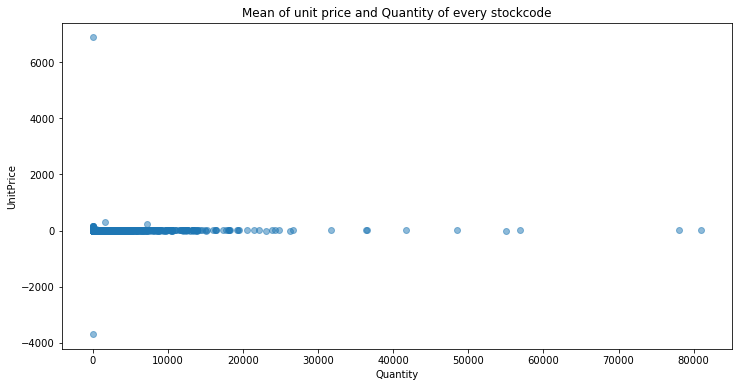

In [52]:
fig, ax = plt.subplots(figsize = (12, 6))

curr = online_rt.groupby(by = 'StockCode').agg({'Quantity': 'sum', 'UnitPrice': 'mean'}).sort_values(by = 'UnitPrice')

ax.plot(curr['Quantity'],
        curr['UnitPrice'],
        'o',
        alpha=0.5)
ax.set(
    xlabel = 'Quantity',
    ylabel = 'UnitPrice',
    title = 'Mean of unit price and Quantity of every stockcode'
)

### Шаг 9. Постройте линейные графики изменения во времени общей суммы продаж и количества заказов по топ-10 странам по Revenue

https://kanoki.org/2020/05/26/dataframe-groupby-date-and-time/

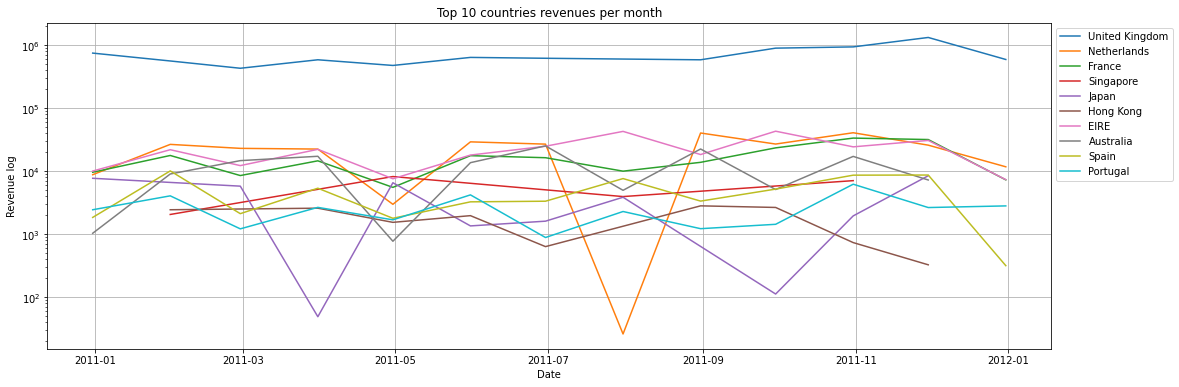

In [232]:
# Countries sorted by Revenue
top_10_countries = online_rt.groupby('Country').agg({'Revenue' : 'max'}).sort_values(by = 'Revenue', ascending=False)

countries_date_revenue = online_rt[['Country', 'InvoiceDate', 'Revenue']].groupby(['Country', pd.Grouper(key='InvoiceDate', freq = 'M')]).sum().reset_index()
countries_date_revenue['Revenue_per_1000'] = round(countries_date_revenue['Revenue']/1000, 2)

fig, ax = plt.subplots(figsize=(18, 6))

for i in top_10_countries.head(10).index:
    ax.plot(countries_date_revenue[countries_date_revenue['Country'] == i]['InvoiceDate'],
            countries_date_revenue[countries_date_revenue['Country'] == i]['Revenue'], label = i)
ax.set(
    yscale = 'log',
    xlabel = 'Date',
    ylabel = 'Revenue log',
    title = 'Top 10 countries revenues per month'

)
plt.legend(bbox_to_anchor=(1, 1))
plt.grid();


### Шаг 10. Проверьте, есть ли покупатели, которые делали заказы в нескольких странах

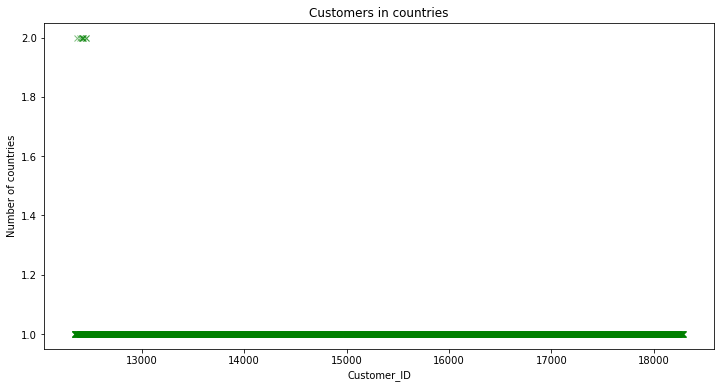

In [235]:
fig, ax = plt.subplots(figsize = (12, 6))



curr = online_rt.groupby(by = 'CustomerID').agg({'Country': 'nunique'}).reset_index()

ax.plot(curr['CustomerID'], 
        curr['Country'],
        'xg',
        alpha = 0.5)
ax.set(
    xlabel = 'Customer_ID',
    ylabel = 'Number of countries',
    title = 'Customers in countries'
);


### Шаг 11. Менялись ли цена на одни и те же товары? Увеличивало ли продажи (по количеству и общей цене) снижение цены? Уменьшало ли продажи увеличение цены?

In [241]:
 online_rt['StockCode'].nunique()

3941

### Бонус: исследуйте датасет дальше, ставя вопросы и отвечая на них с помощью графиков